In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [2]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
df=pd.read_excel("C:\\Users\\gagan\\Downloads\\glass (1).xlsx",sheet_name="glass")

In [4]:
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [5]:
df.shape

(214, 10)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [7]:
df.columns

Index(['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type'], dtype='object')

In [8]:
df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [9]:
df.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [10]:
df.duplicated().sum()

np.int64(1)

In [11]:
df=df.drop_duplicates()

In [12]:
print(df["Type"].value_counts())

Type
2    76
1    69
7    29
3    17
5    13
6     9
Name: count, dtype: int64


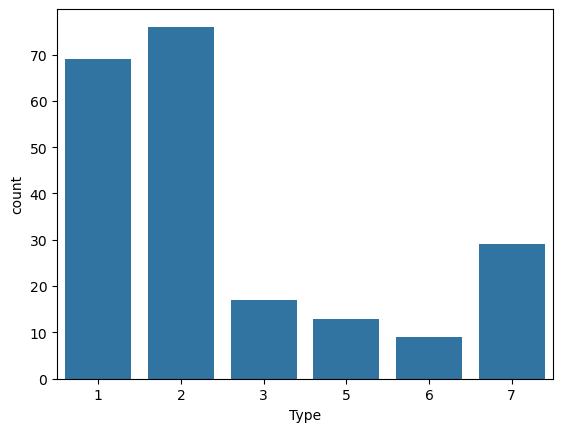

In [13]:
sns.countplot(x="Type",data=df)

plt.show()

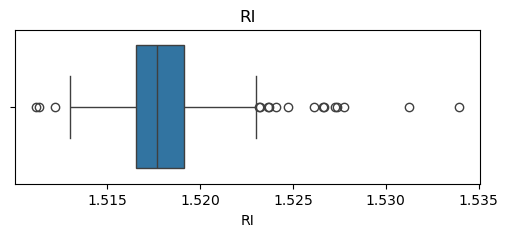

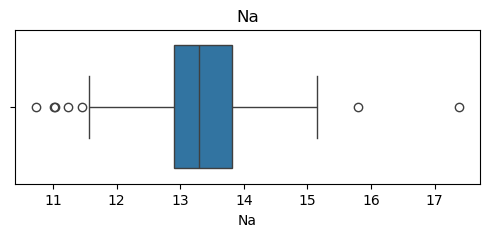

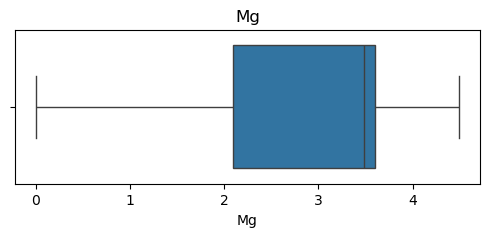

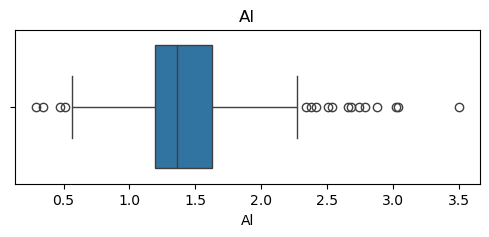

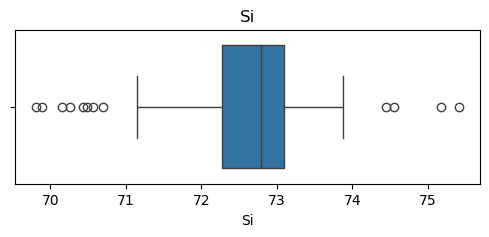

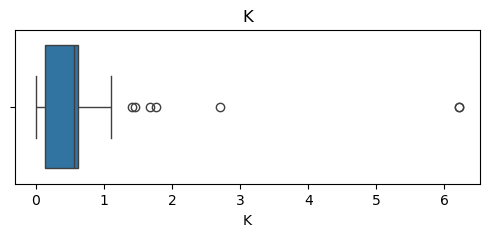

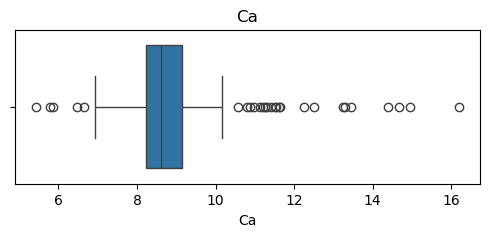

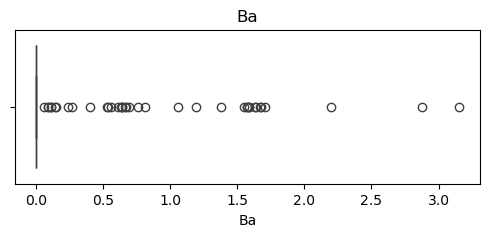

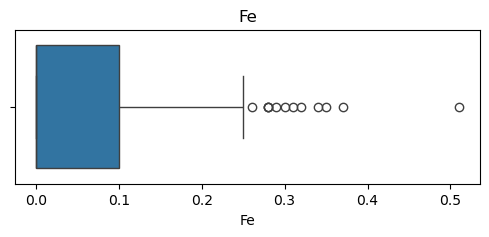

In [14]:
for i in df.columns[:-1]:

    plt.figure(figsize=(6,2))

    sns.boxplot(x=df[i])

    plt.title(i)

    plt.show()

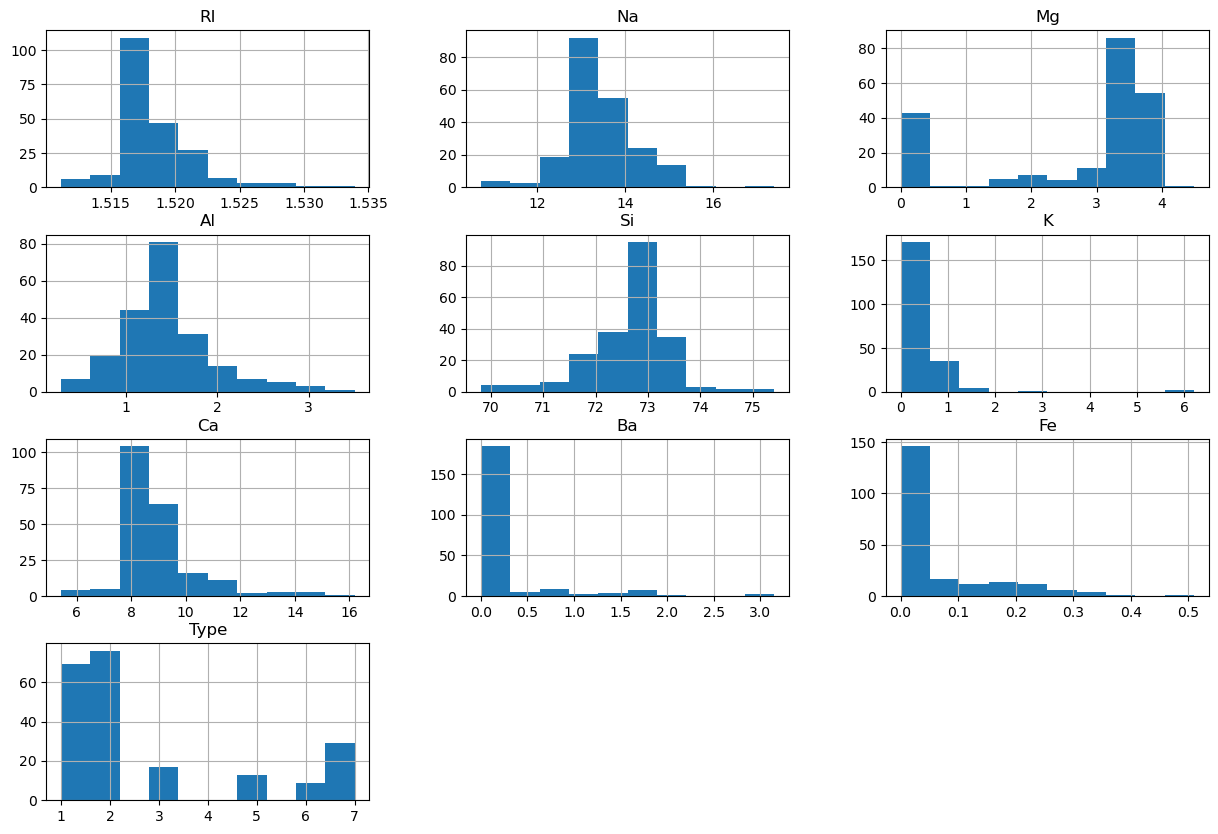

In [15]:
df.hist(figsize=(15,10))

plt.show()

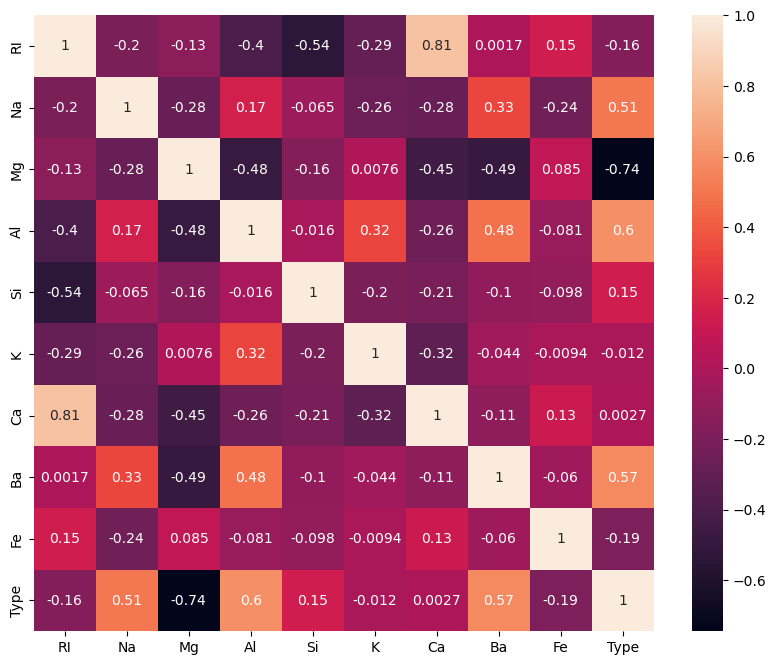

In [16]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(),
            annot=True)

plt.show()

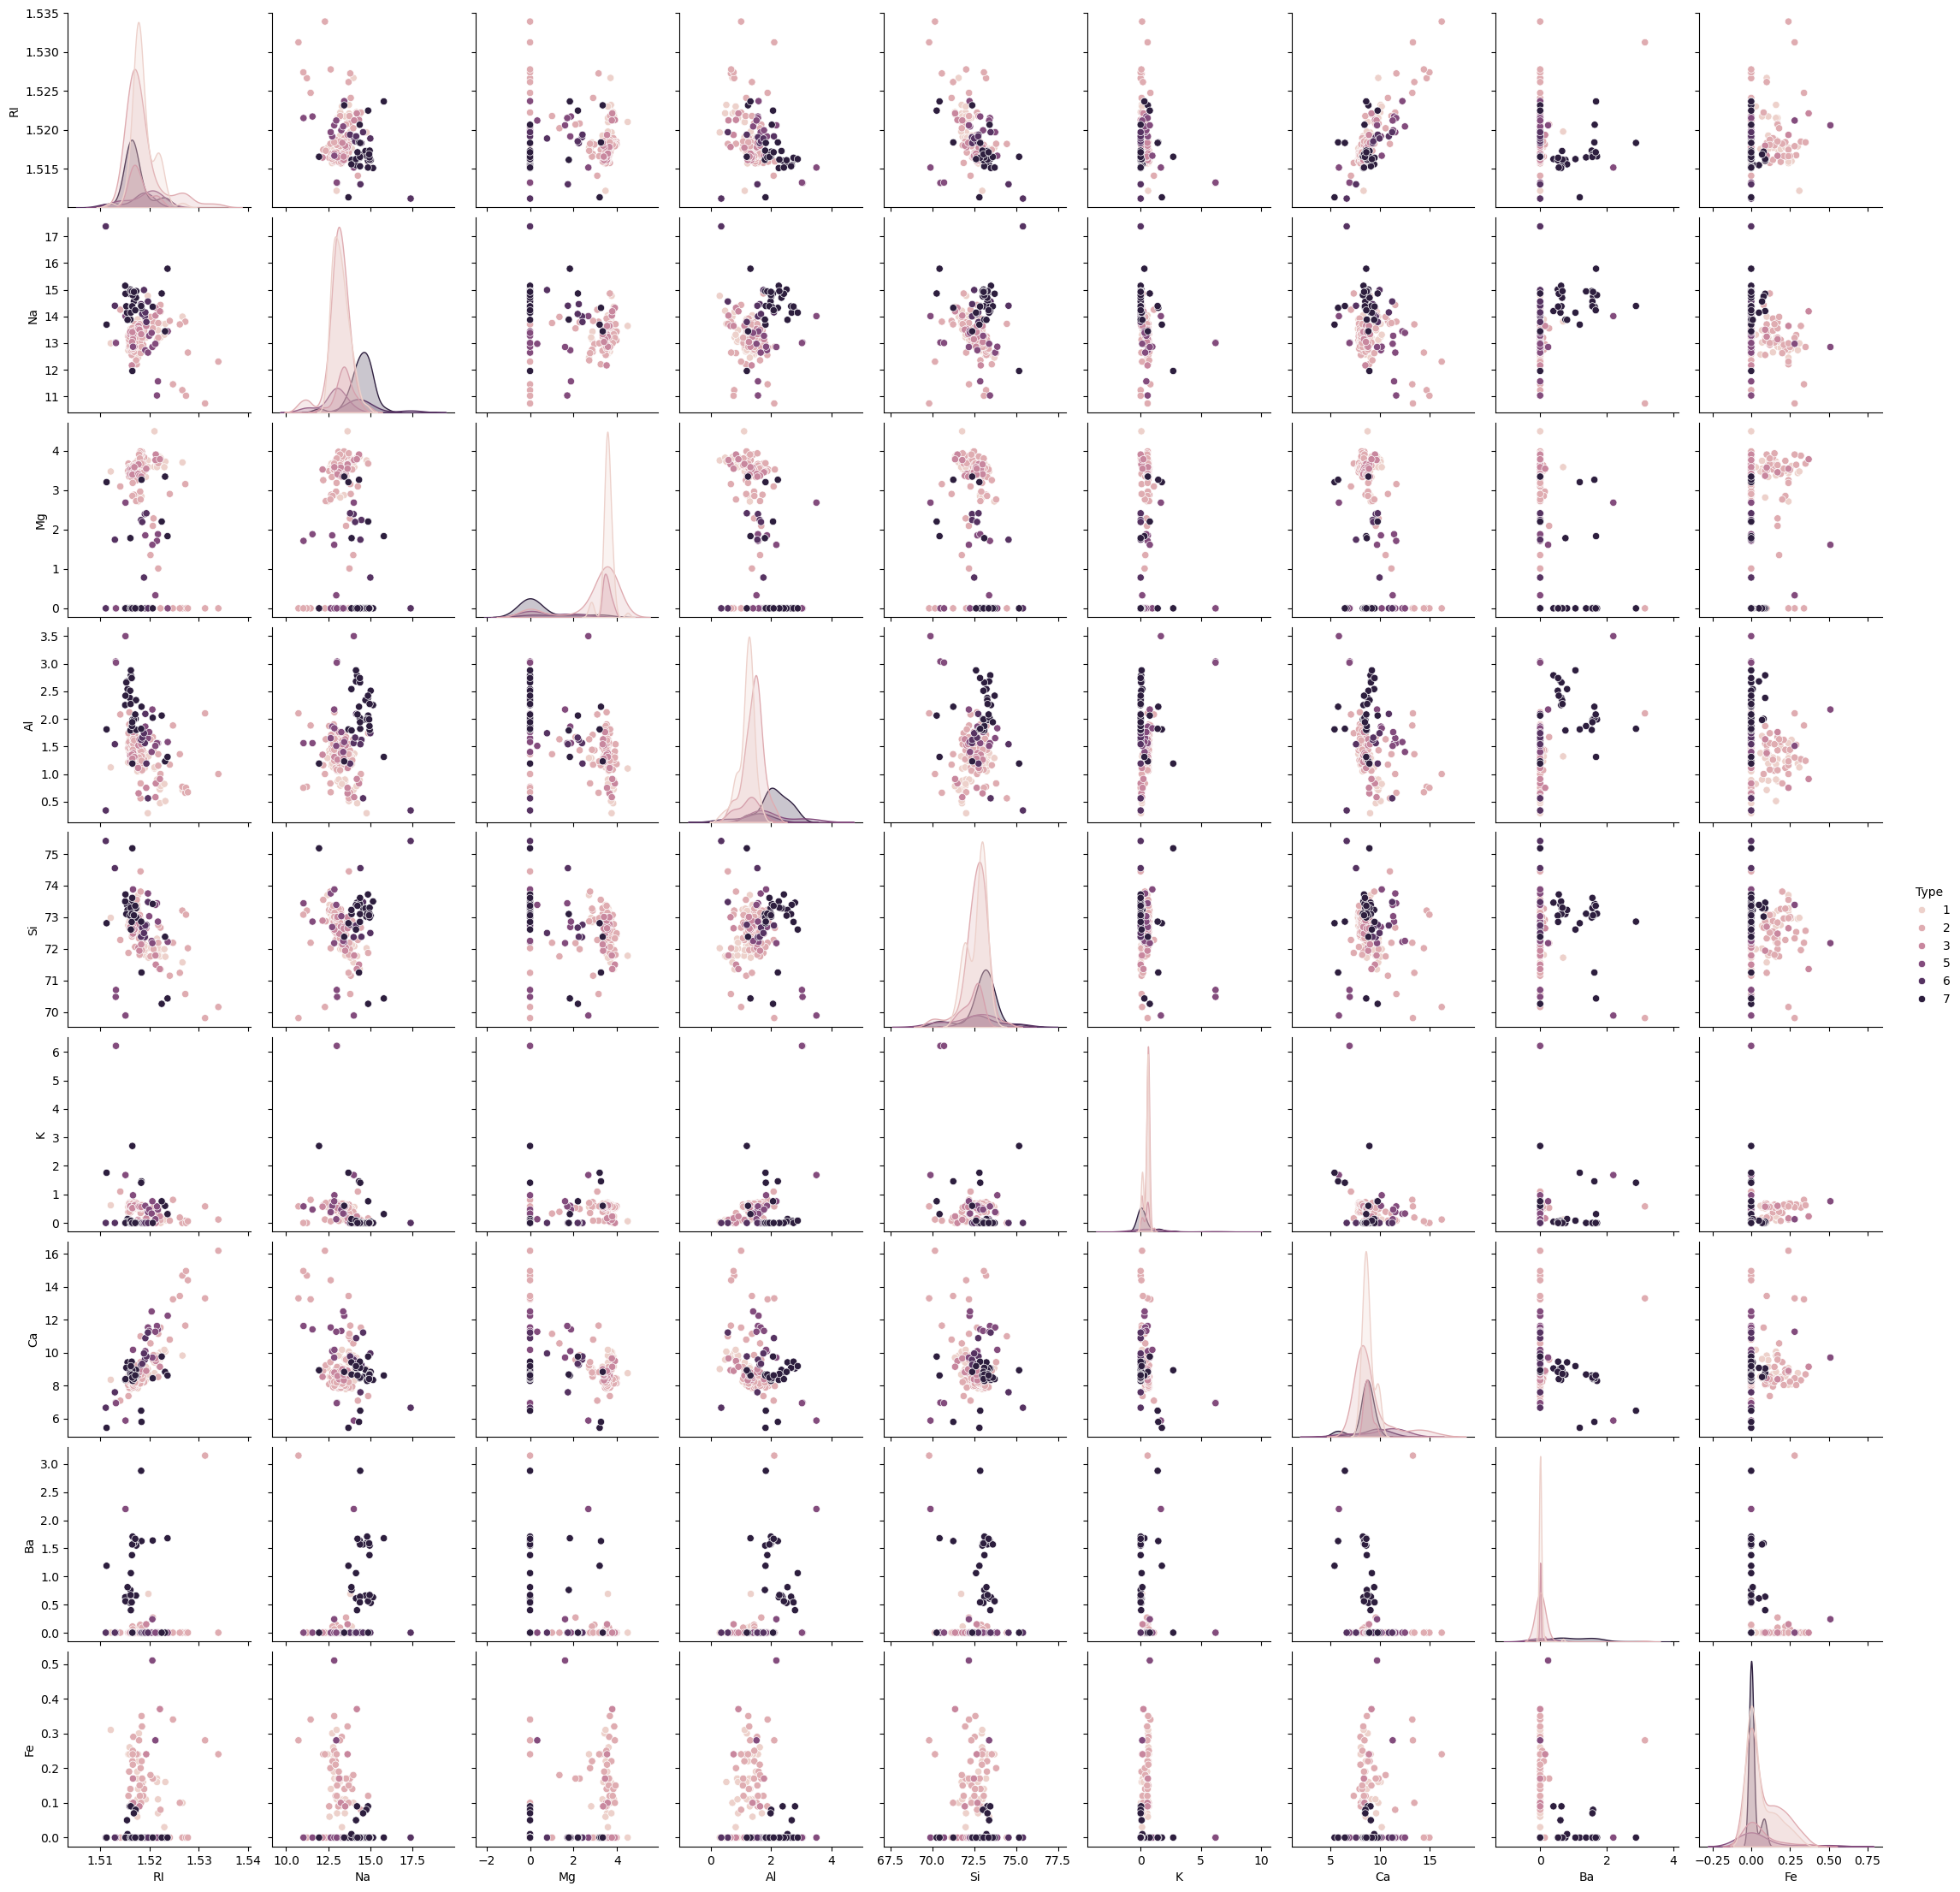

In [20]:
sns.pairplot(df,hue='Type')

plt.show()

In [18]:
df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [21]:
df.fillna(df.mean(),inplace=True)

In [22]:
df.dtypes

RI      float64
Na      float64
Mg      float64
Al      float64
Si      float64
K       float64
Ca      float64
Ba      float64
Fe      float64
Type      int64
dtype: object

In [23]:
X=df.drop("Type",axis=1)

y=df["Type"]

In [24]:
print(y.value_counts())

Type
2    76
1    69
7    29
3    17
5    13
6     9
Name: count, dtype: int64


In [25]:
smote=SMOTE(random_state=42)

X,y=smote.fit_resample(X,y)

In [26]:
print(y.value_counts())

Type
1    76
2    76
3    76
5    76
6    76
7    76
Name: count, dtype: int64


In [27]:
scaler=StandardScaler()

X=scaler.fit_transform(X)

In [28]:
X_train,X_test,y_train,y_test=train_test_split(
X,
y,
test_size=0.20,
random_state=42
)

In [29]:
rf=RandomForestClassifier(
n_estimators=100,
random_state=42
)

In [30]:
rf.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [31]:
y_pred=rf.predict(X_test)

In [32]:
accuracy_score(y_test,y_pred)

0.9565217391304348

In [33]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           1       0.88      0.88      0.88        17
           2       0.94      0.89      0.92        19
           3       0.91      1.00      0.95        10
           5       1.00      1.00      1.00        14
           6       1.00      1.00      1.00        14
           7       1.00      1.00      1.00        18

    accuracy                           0.96        92
   macro avg       0.96      0.96      0.96        92
weighted avg       0.96      0.96      0.96        92



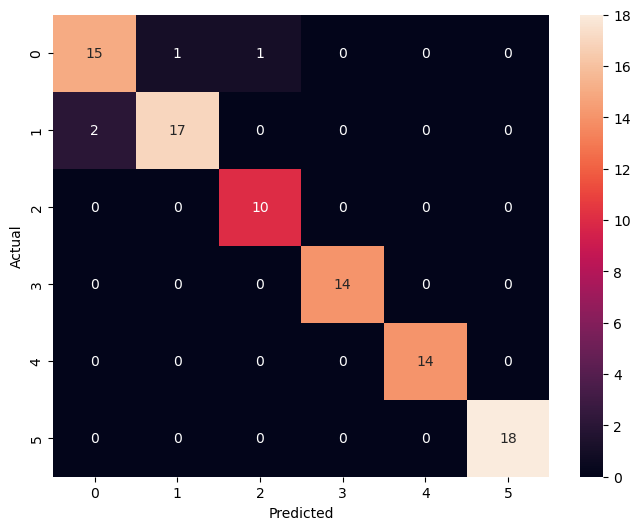

In [34]:
cm=confusion_matrix(y_test,y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(cm,
            annot=True,
            fmt='d')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [35]:
bag=BaggingClassifier(
n_estimators=100,
random_state=42
)

In [36]:
bag.fit(X_train,y_train)

,estimator,None
,n_estimators,100
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,42
,verbose,0


In [37]:
bag_pred=bag.predict(X_test)

In [38]:
print("Bagging Accuracy:")

print(accuracy_score(y_test,bag_pred))

Bagging Accuracy:
0.9130434782608695


In [39]:
print(classification_report(y_test,bag_pred))

              precision    recall  f1-score   support

           1       0.74      0.82      0.78        17
           2       0.94      0.84      0.89        19
           3       0.80      0.80      0.80        10
           5       1.00      1.00      1.00        14
           6       1.00      1.00      1.00        14
           7       1.00      1.00      1.00        18

    accuracy                           0.91        92
   macro avg       0.91      0.91      0.91        92
weighted avg       0.92      0.91      0.91        92



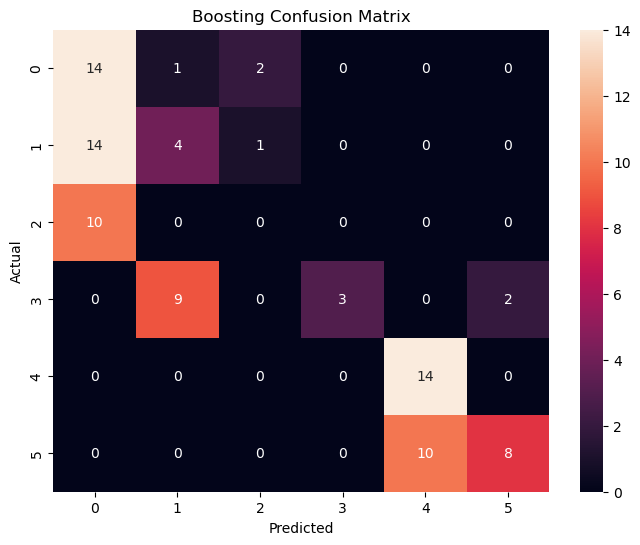

In [47]:
boost=AdaBoostClassifier(
n_estimators=100,
random_state=42
)
cm=confusion_matrix(y_test,boost_pred)

plt.figure(figsize=(8,6))

sns.heatmap(cm,
            annot=True,
            fmt='d')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Boosting Confusion Matrix")

plt.show()

In [41]:
boost.fit(X_train,y_train)

,estimator,None
,n_estimators,100
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,42


In [43]:
print("Boosting Accuracy:")

print(accuracy_score(y_test,boost_pred))

Boosting Accuracy:
0.4673913043478261


In [44]:
print(classification_report(y_test,boost_pred))

              precision    recall  f1-score   support

           1       0.37      0.82      0.51        17
           2       0.29      0.21      0.24        19
           3       0.00      0.00      0.00        10
           5       1.00      0.21      0.35        14
           6       0.58      1.00      0.74        14
           7       0.80      0.44      0.57        18

    accuracy                           0.47        92
   macro avg       0.51      0.45      0.40        92
weighted avg       0.52      0.47      0.42        92



In [45]:
result=pd.DataFrame({

'Model':['Random Forest',
          'Bagging',
          'Boosting'],

'Accuracy':[

accuracy_score(y_test,y_pred),

accuracy_score(y_test,bag_pred),

accuracy_score(y_test,boost_pred)

]

})

print(result)

           Model  Accuracy
0  Random Forest  0.956522
1        Bagging  0.913043
2       Boosting  0.467391


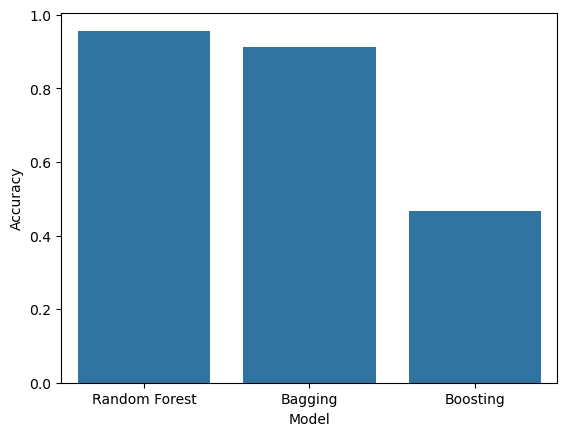

In [46]:
sns.barplot(x='Model',
            y='Accuracy',
            data=result)

plt.show()

In [50]:
result=pd.DataFrame({

'Model':['Random Forest',
          'Bagging',
          'Boosting'],

'Accuracy':[

accuracy_score(y_test,y_pred),

accuracy_score(y_test,bag_pred),

accuracy_score(y_test,boost_pred)

]

})

print(result)

           Model  Accuracy
0  Random Forest  0.956522
1        Bagging  0.913043
2       Boosting  0.467391


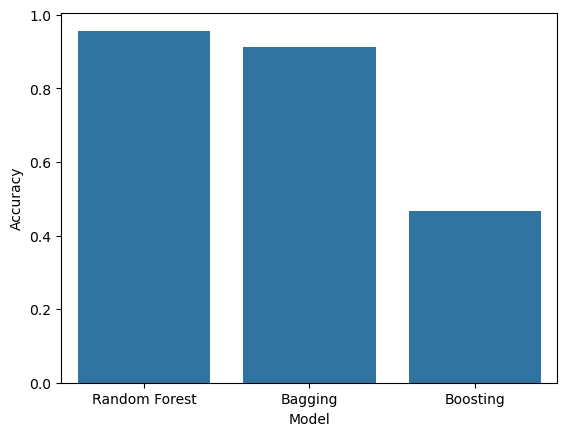

In [51]:
sns.barplot(
x='Model',
y='Accuracy',
data=result)

plt.show()